# Employee Turnover Analytics

## Requirements:

pandas, numpy, matplotlib, seaborn, scikit-learn, imblearn, yellowbrick (optional), joblib

In [1]:
# pip install pandas numpy matplotlib seaborn scikit-learn imblearn yellowbrick joblib

Looking in indexes: https://artifacts.dell.com/artifactory/api/pypi/python/simple, https://artifacts.dell.com/artifactory/api/pypi/ailfc-1003745-pypi-prd-local/simple, https://artifacts.dell.com/artifactory/api/pypi/aia-1001238-pypi-prd-local/simple, https://artifacts.dell.com/artifactory/api/pypi/aiops-1002685-pypi-prd-local/simple
  Using cached https://artifacts.dell.com/artifactory/api/pypi/python/packages/packages/7d/18/95ae2e242d4a5c98bd6e90e36e128d71cf1c7e39b0874feaed3ef782e789/matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
  Using cached https://artifacts.dell.com/artifactory/api/pypi/python/packages/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached https://artifacts.dell.com/artifactory/api/pypi/python/packages/packages/5c/d0/0c577d9325b05594fdd33aa970bf53fb673f051a45496842caee13cfd7fe/scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64

## Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import joblib

plt.rcParams['figure.figsize'] = (8,6)

## 0. Data load
- Place the dataset file in the working directory with name 'HR_comma_sep.csv'.
- If you have it under a different path, modify the variable csv_path accordingly.

In [3]:
csv_path = 'HR_comma_sep.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset not found: {csv_path}. Download from Kaggle and place it as 'HR_comma_sep.csv'.")

df = pd.read_csv(csv_path)

## 1. Data quality checks

In [5]:
print('\n-- Shape and dtypes --')
print(df.shape)
print(df.dtypes)

print('\n-- Missing values per column --')
print(df.isnull().sum())

print('\n-- Basic stats for numeric columns --')
print(df.describe().T)


-- Shape and dtypes --
(14999, 10)
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object

-- Missing values per column --
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

-- Basic stats for numeric columns --
                         count        mean        std    min     25%     50%  \
satisfaction_level     14999.0    0.612834   0.248631   0.09    0.44    0.64   
last_evaluation        14999.0    0.716102   0.171169   0.36    0.56    0.72   
number_project         14

## 2. Understand factors contributing most to turnover

### 2.1 Correlation heatmap of numerical features

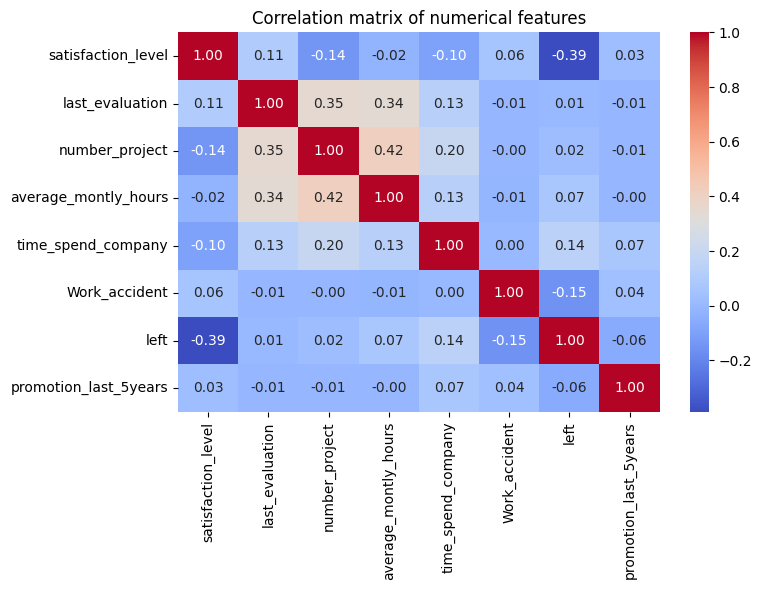

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
plt.figure()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix of numerical features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

### 2.2 Distribution plots for satisfaction_level, last_evaluation, average_montly_hours

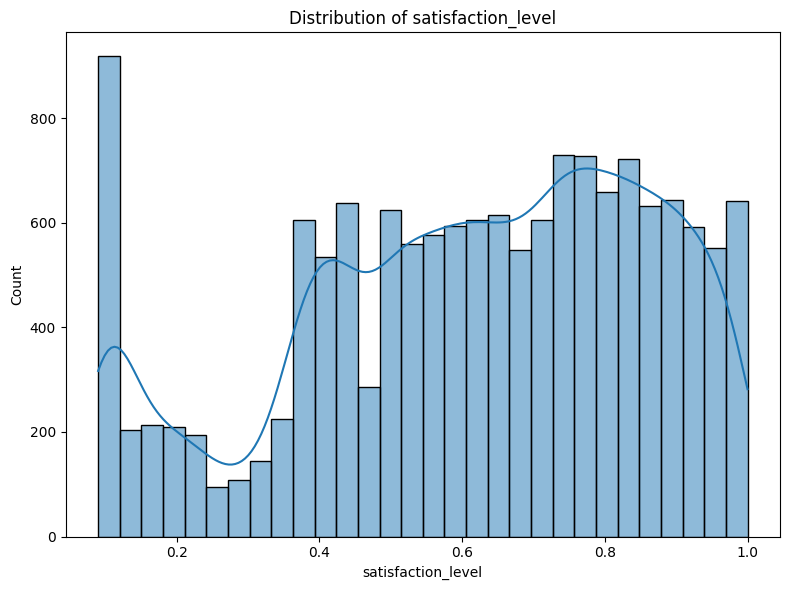

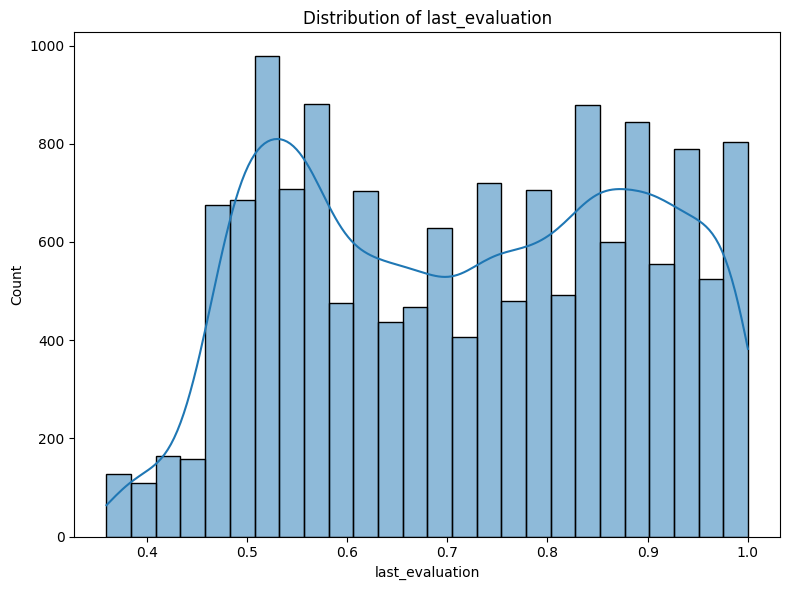

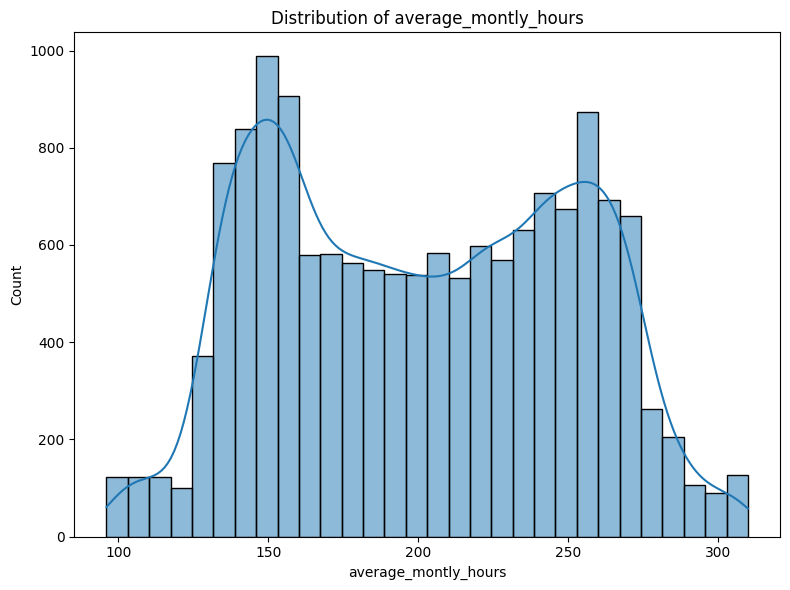

In [7]:
for col in ['satisfaction_level', 'last_evaluation', 'average_montly_hours']:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f'dist_{col}.png')

### 2.3 Bar plot: number_project vs left

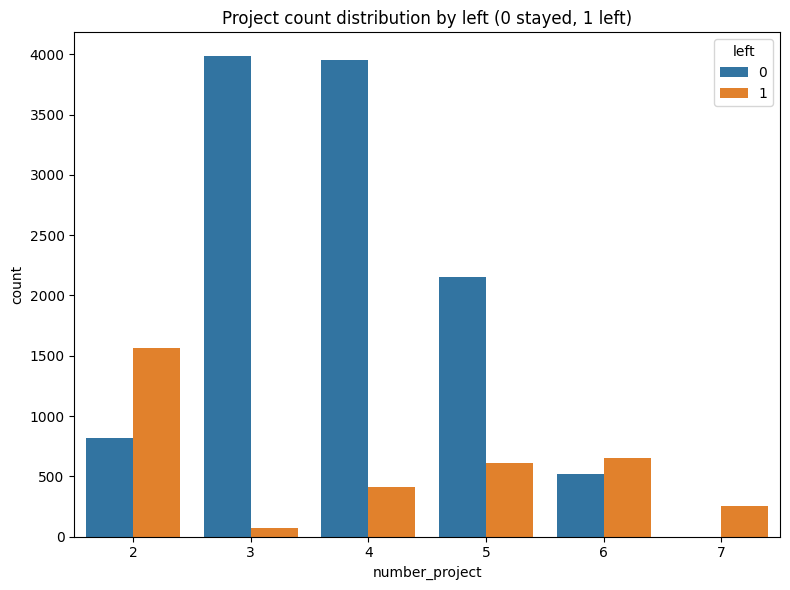

In [8]:
plt.figure()
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Project count distribution by left (0 stayed, 1 left)')
plt.tight_layout()
plt.savefig('projects_by_left.png')

#### Quick inferences (printed as short bullet-style lines)

In [9]:

proj_tab = pd.crosstab(df['number_project'], df['left'], normalize='index') * 100
print('\n-- Percentage of employees who left by number_project (rows sum to 100) --')
print(proj_tab.round(2))


-- Percentage of employees who left by number_project (rows sum to 100) --
left                0       1
number_project               
2               34.38   65.62
3               98.22    1.78
4               90.63    9.37
5               77.83   22.17
6               44.21   55.79
7                0.00  100.00


## 3. Clustering of employees who left based on satisfaction and evaluation

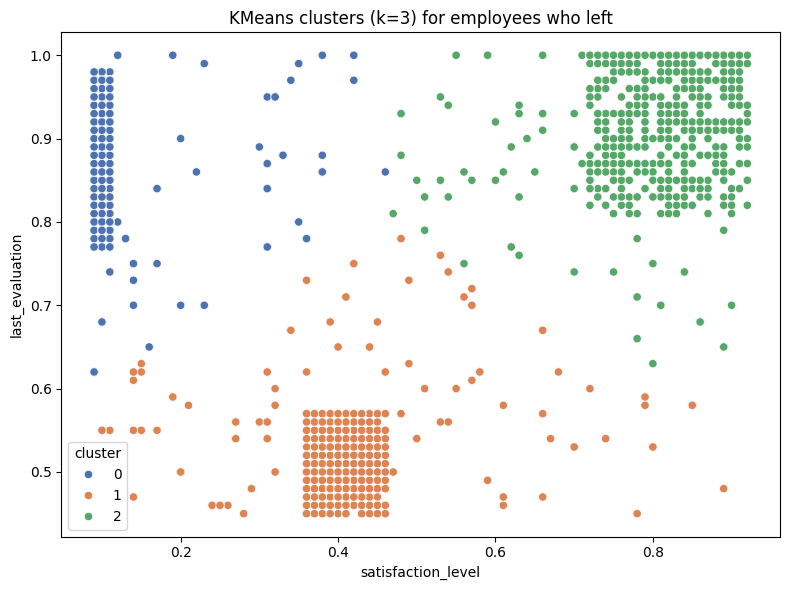

In [10]:
left_df = df[df['left'] == 1].copy()
cluster_cols = ['satisfaction_level', 'last_evaluation']
X_cluster = left_df[cluster_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
left_df = left_df.loc[X_cluster.index]
left_df['cluster'] = clusters

plt.figure()
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='deep')
plt.title('KMeans clusters (k=3) for employees who left')
plt.tight_layout()
plt.savefig('kmeans_left_clusters.png')

#### Print cluster centers (in original feature scale)

In [11]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=cluster_cols)
print('\n-- Cluster centers for employees who left --')
print(centers_df)


-- Cluster centers for employees who left --
   satisfaction_level  last_evaluation
0            0.111321         0.870884
1            0.412304         0.517265
2            0.808031         0.916415


## 4. Handle class imbalance using SMOTE after preprocessing

### 4.1 Preprocess categorical to numeric via get_dummies

In [17]:
cat_cols = ['sales', 'salary']
num_cols = [c for c in df.columns if c not in cat_cols + ['left']]

cat_df = pd.get_dummies(df[cat_cols], drop_first=True)
num_df = df[num_cols].copy()
processed = pd.concat([num_df, cat_df], axis=1)
processed['left'] = df['left'].values

print('\n-- Processed features shape --')
print(processed.shape)


-- Processed features shape --
(14999, 19)


## 5. Stratified split and SMOTE on train

In [18]:
X = processed.drop('left', axis=1)
y = processed['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)
print('\n-- Train class distribution before SMOTE --')
print(y_train.value_counts())

sm = SMOTE(random_state=123)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('\n-- Train class distribution after SMOTE --')
print(y_train_sm.value_counts())


-- Train class distribution before SMOTE --
left
0    9142
1    2857
Name: count, dtype: int64

-- Train class distribution after SMOTE --
left
0    9142
1    9142
Name: count, dtype: int64


### 5.1-5.3 Model training with 5-fold cross-validation, classification reports for each model

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=123),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=123),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=123)
}

cv_results = {}
roc_auc_scores = {}
conf_matrices = {}
class_reports = {}

for name, model in models.items():
    print(f"\n-- Training and cross-val for: {name} --")
    # Use cross_val_predict on the SMOTE-resampled training set to get cv predictions
    y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=skf, method='predict')
    y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=skf, method='predict_proba')[:,1]

    # Fit final model on entire SMOTE training set
    model.fit(X_train_sm, y_train_sm)
    joblib.dump(model, f'{name}_model.joblib')

    # Evaluate on held-out test set
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:,1]

    report = classification_report(y_test, y_test_pred, output_dict=True)
    class_reports[name] = report
    conf = confusion_matrix(y_test, y_test_pred)
    conf_matrices[name] = conf
    auc_score = roc_auc_score(y_test, y_test_proba)
    roc_auc_scores[name] = auc_score

    print(f"Test ROC AUC for {name}: {auc_score:.4f}")
    print('Confusion matrix:')
    print(conf)
    print('Classification report:')
    print(pd.DataFrame(report).T)


-- Training and cross-val for: LogisticRegression --
Test ROC AUC for LogisticRegression: 0.8153
Confusion matrix:
[[1768  518]
 [ 184  530]]
Classification report:
              precision    recall  f1-score   support
0              0.905738  0.773403  0.834356  2286.000
1              0.505725  0.742297  0.601589   714.000
accuracy       0.766000  0.766000  0.766000     0.766
macro avg      0.705731  0.757850  0.717972  3000.000
weighted avg   0.810535  0.766000  0.778957  3000.000

-- Training and cross-val for: RandomForest --
Test ROC AUC for RandomForest: 0.9950
Confusion matrix:
[[2269   17]
 [  15  699]]
Classification report:
              precision    recall  f1-score      support
0              0.993433  0.992563  0.992998  2286.000000
1              0.976257  0.978992  0.977622   714.000000
accuracy       0.989333  0.989333  0.989333     0.989333
macro avg      0.984845  0.985778  0.985310  3000.000000
weighted avg   0.989345  0.989333  0.989338  3000.000000

-- Training a

## 6. Compare ROC curves

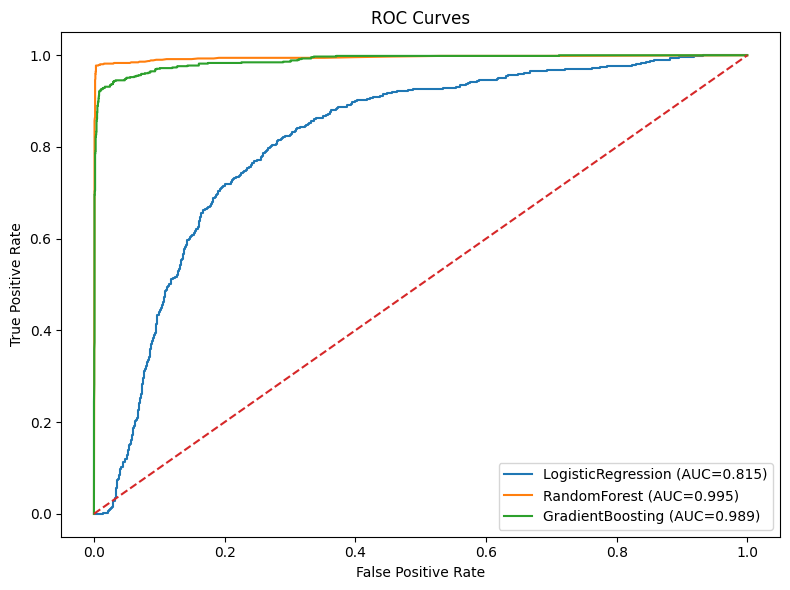

In [20]:
plt.figure()
for name, model in models.items():
    m = joblib.load(f'{name}_model.joblib')
    y_proba = m.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_scores[name]:.3f})")

plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparison.png')

### 6.1 Choose best model: based on ROC AUC and recall for positive class

In [21]:
print('\n-- ROC AUC scores summary --')
for name, score in roc_auc_scores.items():
    print(f"{name}: {score:.4f}")

# Compute recall for positive class from test confusion matrices
print('\n-- Recall for left class (1) from confusion matrices --')
for name, conf in conf_matrices.items():
    tn, fp, fn, tp = conf.ravel()
    recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{name}: Recall={recall_pos:.4f}, Precision={precision_pos:.4f}")


-- ROC AUC scores summary --
LogisticRegression: 0.8153
RandomForest: 0.9950
GradientBoosting: 0.9890

-- Recall for left class (1) from confusion matrices --
LogisticRegression: Recall=0.7423, Precision=0.5057
RandomForest: Recall=0.9790, Precision=0.9763
GradientBoosting: Recall=0.9314, Precision=0.9275


- Decision: prioritize Recall for left=1 to catch potential leavers for retention actions.
- Select best model as the one with highest AUC and adequate recall. We'll pick by AUC primarily.

In [22]:
best_model_name = max(roc_auc_scores, key=lambda k: roc_auc_scores[k])
best_model = joblib.load(f'{best_model_name}_model.joblib')
print(f"\n-- Best model selected by ROC AUC: {best_model_name} --")


-- Best model selected by ROC AUC: RandomForest --


## 7. Confusion matrices printed above; discussion of which metric to use:
For employee turnover, missing a leaver is costlier than mistakenly flagging a stayer. Use Recall.

### 7.1 Predict probability on test set and categorize into zones

In [23]:
y_test_probs = best_model.predict_proba(X_test)[:,1]

zones = pd.DataFrame({'prob': y_test_probs, 'true': y_test.values})

def zone_label(p):
    if p < 0.20:
        return 'Green'
    if p < 0.60:
        return 'Yellow'
    if p < 0.90:
        return 'Orange'
    return 'Red'

zones['zone'] = zones['prob'].apply(zone_label)
zone_counts = zones['zone'].value_counts()
print('\n-- Zone counts on test set --')
print(zone_counts)


-- Zone counts on test set --
zone
Green     2172
Red        652
Yellow     121
Orange      55
Name: count, dtype: int64


### 7.2 Retention strategies per zone (printed succinctly)

In [24]:
retention_strategies = {
    'Green': [
        'No immediate action. Monitor periodic performance and satisfaction metrics.'
    ],
    'Yellow': [
        'Targeted engagement: manager 1:1, career-path conversation, small incentives, flexible hours.'
    ],
    'Orange': [
        'Proactive retention: tailored development plan, promotion consideration, raise/bonus review, workload assessment.'
    ],
    'Red': [
        'Immediate intervention: retention offer, senior leadership touchpoint, offboarding risk mitigation, knowledge transfer plan.'
    ]
}

print('\n-- Retention strategy examples per zone --')
for z, s in retention_strategies.items():
    print(f"{z}: {s[0]}")


-- Retention strategy examples per zone --
Green: No immediate action. Monitor periodic performance and satisfaction metrics.
Yellow: Targeted engagement: manager 1:1, career-path conversation, small incentives, flexible hours.
Orange: Proactive retention: tailored development plan, promotion consideration, raise/bonus review, workload assessment.
Red: Immediate intervention: retention offer, senior leadership touchpoint, offboarding risk mitigation, knowledge transfer plan.


## Save zone assignments with features for HR actions

In [25]:
X_test_out = X_test.copy()
X_test_out['prob_left'] = y_test_probs
X_test_out['zone'] = zones['zone'].values
X_test_out['true_left'] = y_test.values
X_test_out.to_csv('test_set_predictions_with_zones.csv', index=False)

print('\nOutputs saved: correlation_heatmap.png, dist_*.png, projects_by_left.png, kmeans_left_clusters.png, roc_comparison.png, test_set_predictions_with_zones.csv')



Outputs saved: correlation_heatmap.png, dist_*.png, projects_by_left.png, kmeans_left_clusters.png, roc_comparison.png, test_set_predictions_with_zones.csv
